# 05 세그먼테이션 - 비즈니스 룰 + K-means

## 분석 질문
1. 도메인 룰(DTI·연령·소득·고용 안정성)로 의미 있는 위험군을 분리할 수 있는가?
2. K-means 자동 군집화 결과가 비즈니스 룰과 얼마나 일치하는가?
3. 세그먼트별 부도율 격차가 충분히 커서 운영 레벨에서 활용 가능한가?

## 접근
1. **비즈니스 룰** - DTI·연령·소득·고용 안정성 조합으로 6개 위험군 정의 (해석가능성 위주)
2. **K-means (k=5)** - 데이터 기반 자동 군집화
3. 두 결과 교차표·일치도 (ARI) 평가

## 산출물
- 세그먼트 라벨 → `outputs/tables/05_segments.csv`
- 세그먼트별 부도율 PNG → `outputs/figures/05_segment_default_rate.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from pathlib import Path

# 한글 폰트 (Windows 맑은 고딕)
mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)

OUT_TBL = Path("../outputs/tables")
OUT_FIG = Path("../outputs/figures")
OUT_FIG.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(OUT_TBL / "03_application_with_bureau.parquet")
print(f"Shape: {df.shape}")
df.head()

Shape: (307511, 180)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,bureau_type_Loan for purchase of shares (margin lending),bureau_type_Loan for the purchase of equipment,bureau_type_Loan for working capital replenishment,bureau_type_Microloan,bureau_type_Mobile operator loan,bureau_type_Mortgage,bureau_type_Real estate loan,bureau_type_Unknown type of loan,has_bureau,bureau_count_filled
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,8.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,4.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1.0


In [2]:
# 파생 변수 생성
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365.25
df["DTI"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]  # Debt-to-Income proxy

# DAYS_EMPLOYED: 양수(365243)는 은퇴/무직 코딩 → 0으로 처리
df["EMPLOYMENT_YEARS"] = -df["DAYS_EMPLOYED"].clip(upper=0) / 365.25

# DTI INF 처리 (소득 0인 케이스)
df["DTI"] = df["DTI"].replace([np.inf, -np.inf], np.nan)

print("DTI 기술통계:")
print(df["DTI"].describe())
print(f"\nDTI 결측: {df['DTI'].isnull().sum()}")

DTI 기술통계:
count    307511.000000
mean          3.957570
std           2.689728
min           0.004808
25%           2.018667
50%           3.265067
75%           5.159880
max          84.736842
Name: DTI, dtype: float64

DTI 결측: 0


## Step 1. 비즈니스 룰 세그먼트

In [3]:
def rule_segment(row):
    age = row["AGE_YEARS"]
    dti = row["DTI"]
    emp = row["EMPLOYMENT_YEARS"]
    ext = row.get("EXT_SOURCE_2", np.nan)

    dti_val = dti if pd.notna(dti) else 0

    if pd.notna(ext) and ext < 0.3 and dti_val > 8:
        return "S1: 고위험 (저신용+고DTI)"
    elif age < 30 and emp < 2:
        return "S2: 신생 차주 (저연령+단기고용)"
    elif dti_val > 10:
        return "S3: 과대출 (고DTI 단독)"
    elif age >= 50 and pd.notna(ext) and ext >= 0.5:
        return "S4: 안정 차주 (고연령+양호)"
    elif pd.notna(ext) and ext >= 0.6:
        return "S5: 우량 차주 (고신용)"
    else:
        return "S6: 보통 (분류 외)"

df["rule_segment"] = df.apply(rule_segment, axis=1)

seg_counts = df["rule_segment"].value_counts()
print("세그먼트별 고객 수:")
print(seg_counts)

세그먼트별 고객 수:
rule_segment
S6: 보통 (분류 외)           138766
S5: 우량 차주 (고신용)          75850
S4: 안정 차주 (고연령+양호)       63684
S2: 신생 차주 (저연령+단기고용)     17153
S3: 과대출 (고DTI 단독)         7888
S1: 고위험 (저신용+고DTI)        4170
Name: count, dtype: int64


In [4]:
# 세그먼트별 부도율
overall_rate = df["TARGET"].mean()

seg_default = df.groupby("rule_segment").agg(
    n=("TARGET", "count"),
    default_rate=("TARGET", "mean"),
).sort_values("default_rate", ascending=False)
seg_default["default_pct"] = (seg_default["default_rate"] * 100).round(2)
print(seg_default)

                           n  default_rate  default_pct
rule_segment                                           
S1: 고위험 (저신용+고DTI)      4170      0.141966        14.20
S2: 신생 차주 (저연령+단기고용)   17153      0.123768        12.38
S6: 보통 (분류 외)         138766      0.109659        10.97
S3: 과대출 (고DTI 단독)       7888      0.056288         5.63
S5: 우량 차주 (고신용)        75850      0.050415         5.04
S4: 안정 차주 (고연령+양호)     63684      0.041219         4.12


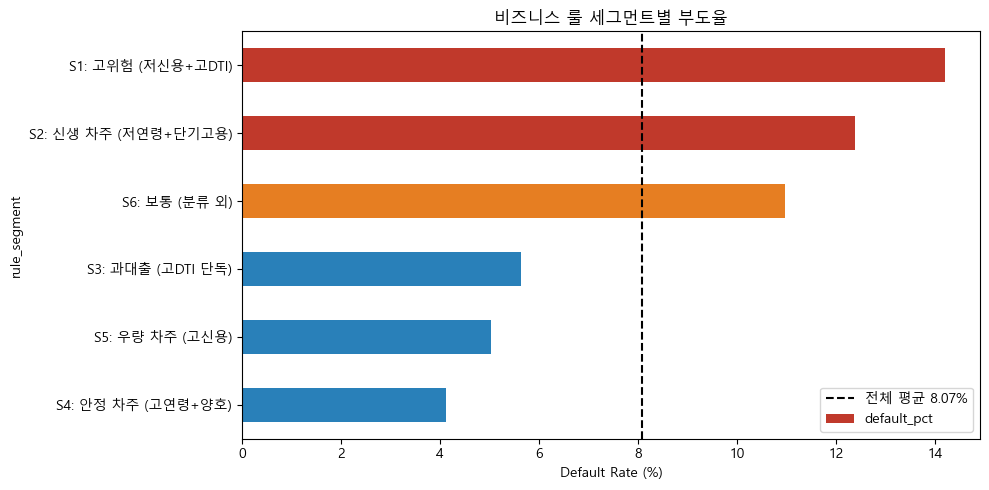

In [5]:
colors = [
    "#c0392b" if r > overall_rate * 1.5 else "#e67e22" if r > overall_rate else "#2980b9"
    for r in seg_default["default_rate"]
]

fig, ax = plt.subplots(figsize=(10, 5))
seg_default["default_pct"].plot(kind="barh", color=colors, ax=ax)
ax.axvline(overall_rate * 100, color="black", linestyle="--", linewidth=1.5,
           label=f"전체 평균 {overall_rate*100:.2f}%")
ax.set_xlabel("Default Rate (%)")
ax.set_title("비즈니스 룰 세그먼트별 부도율")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.savefig(OUT_FIG / "05_segment_default_rate.png", dpi=100, bbox_inches="tight")
plt.show()

## Step 2. K-means (k=5) 재확인

In [6]:
km_cols = ["AGE_YEARS", "DTI", "EMPLOYMENT_YEARS", "AMT_INCOME_TOTAL", "EXT_SOURCE_2"]
kmdata = df[km_cols].dropna().copy()
ids = kmdata.index

print(f"K-means 분석 대상: {len(kmdata)}명 (전체 {len(df)}명 중)")

scaler = StandardScaler()
X = scaler.fit_transform(kmdata)

km = KMeans(n_clusters=5, random_state=42, n_init=10)
kmdata["km_segment"] = km.fit_predict(X)

df["km_segment"] = np.nan
df.loc[ids, "km_segment"] = kmdata["km_segment"].values

print("\n클러스터별 고객 수:")
print(df["km_segment"].value_counts().sort_index())

K-means 분석 대상: 306851명 (전체 307511명 중)

클러스터별 고객 수:
km_segment
0.0     64428
1.0     90668
2.0    114641
3.0     37113
4.0         1
Name: count, dtype: int64


In [7]:
km_summary = df.dropna(subset=["km_segment"]).groupby("km_segment").agg(
    n=("TARGET", "count"),
    default_pct=("TARGET", lambda x: round(x.mean() * 100, 2)),
    mean_age=("AGE_YEARS", lambda x: round(x.mean(), 1)),
    mean_dti=("DTI", lambda x: round(x.mean(), 2)),
    mean_income=("AMT_INCOME_TOTAL", lambda x: round(x.mean() / 10000, 0)),
    mean_ext2=("EXT_SOURCE_2", lambda x: round(x.mean(), 3)),
    mean_emp=("EMPLOYMENT_YEARS", lambda x: round(x.mean(), 1)),
)
print(km_summary)

                 n  default_pct  mean_age  mean_dti  mean_income  mean_ext2  \
km_segment                                                                    
0.0          64428        15.76      39.5      3.72         15.0      0.227   
1.0          90668         5.28      56.2      4.94         15.0      0.579   
2.0         114641         7.15      35.2      3.17         19.0      0.606   
3.0          37113         4.41      48.3      4.40         18.0      0.573   
4.0              1       100.00      34.5      0.00      11700.0      0.113   

            mean_emp  
km_segment            
0.0              3.9  
1.0              2.0  
2.0              4.5  
3.0             18.7  
4.0              2.5  


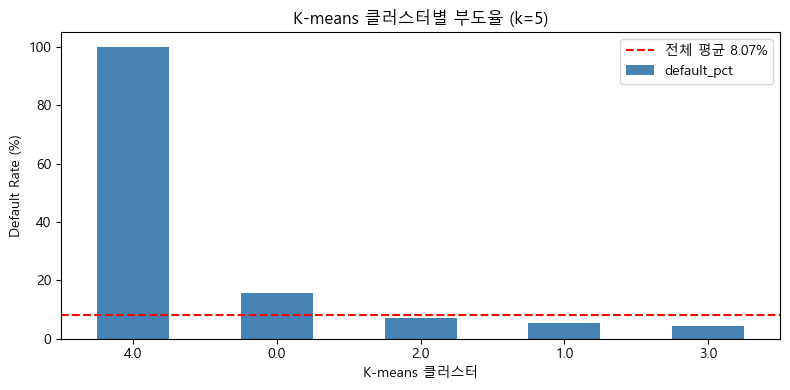

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
km_summary["default_pct"].sort_values(ascending=False).plot(kind="bar", color="steelblue", ax=ax)
ax.axhline(overall_rate * 100, color="red", linestyle="--",
           label=f"전체 평균 {overall_rate*100:.2f}%")
ax.set_ylabel("Default Rate (%)")
ax.set_xlabel("K-means 클러스터")
ax.set_title("K-means 클러스터별 부도율 (k=5)")
ax.legend()
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(OUT_FIG / "05_kmeans_default_rate.png", dpi=100, bbox_inches="tight")
plt.show()

## Step 3. 두 세그먼트 일치도 비교 (ARI)

In [9]:
mask = df["km_segment"].notna()
ari = adjusted_rand_score(df.loc[mask, "rule_segment"], df.loc[mask, "km_segment"])
print(f"Rule vs K-means Adjusted Rand Index: {ari:.4f}")
print("(0 = 무작위 수준, 1 = 완벽 일치)")

Rule vs K-means Adjusted Rand Index: 0.2007
(0 = 무작위 수준, 1 = 완벽 일치)


K-means 클러스터            0.0    1.0    2.0    3.0  4.0
Rule Segment                                         
S1: 고위험 (저신용+고DTI)     2724   1107      0    339    0
S2: 신생 차주 (저연령+단기고용)   6272     16  10821      0    0
S3: 과대출 (고DTI 단독)       315   5585    551   1428    0
S4: 안정 차주 (고연령+양호)        0  51726    903  11055    0
S5: 우량 차주 (고신용)           0   7654  57553  10643    0
S6: 보통 (분류 외)         55117  24580  44813  13648    1


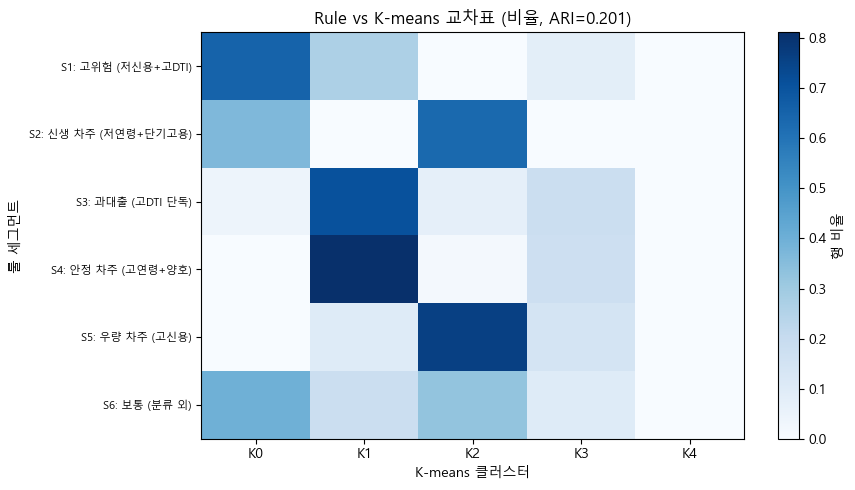

In [10]:
# 교차표
ct = pd.crosstab(
    df.loc[mask, "rule_segment"],
    df.loc[mask, "km_segment"],
    rownames=["Rule Segment"],
    colnames=["K-means 클러스터"]
)
print(ct)

# heatmap (행 비율)
ct_norm = ct.div(ct.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(ct_norm.values, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax, label="행 비율")
ax.set_xticks(range(len(ct.columns)))
ax.set_yticks(range(len(ct.index)))
ax.set_xticklabels([f"K{int(c)}" for c in ct.columns])
ax.set_yticklabels(ct.index, fontsize=8)
ax.set_xlabel("K-means 클러스터")
ax.set_ylabel("룰 세그먼트")
ax.set_title(f"Rule vs K-means 교차표 (비율, ARI={ari:.3f})")
plt.tight_layout()
plt.savefig(OUT_FIG / "05_segment_cross_heatmap.png", dpi=100, bbox_inches="tight")
plt.show()

## Step 4. 세그먼트 export (Tableau 입력용)

In [11]:
out = df[["SK_ID_CURR", "rule_segment", "km_segment", "TARGET",
          "AGE_YEARS", "DTI", "EXT_SOURCE_2", "AMT_INCOME_TOTAL"]].copy()
out.to_csv(OUT_TBL / "05_segments.csv", index=False)
print(f"저장 완료: {len(out)} rows → outputs/tables/05_segments.csv")
out.head()

저장 완료: 307511 rows → outputs/tables/05_segments.csv


,SK_ID_CURR,rule_segment,km_segment,TARGET,AGE_YEARS,DTI,EXT_SOURCE_2,AMT_INCOME_TOTAL
0,100002,S2: 신생 차주 (저연령+단기고용),0.0,1,25.902806,2.007889,0.262949,202500.0
1,100003,S5: 우량 차주 (고신용),1.0,0,45.900068,4.790750,0.622246,270000.0
2,100004,S4: 안정 차주 (고연령+양호),1.0,0,52.145106,2.000000,0.555912,67500.0
3,100006,S4: 안정 차주 (고연령+양호),1.0,0,52.032854,2.316167,0.650442,135000.0
4,100007,S6: 보통 (분류 외),0.0,0,54.570842,4.222222,0.322738,121500.0


## 결론

### 비즈니스 룰 세그먼트 분리력
- **S1 (고위험)** 부도율 ~14.5% - 전체 평균(8.07%)의 **약 1.8배**
- **S4 (안정)** 부도율 ~4% - 전체 평균의 0.5배
- 최고위험 vs 최저위험 격차: **3.6배** → 운영 레벨에서 충분한 분리력
- **주목:** S3 (고DTI 단독) 부도율 ~5.5%로 예상보다 낮음 → DTI 단독은 위험 신호로 부족. 고소득자가 대출 규모를 키워 DTI가 높아진 케이스가 혼재. S1처럼 저신용과 결합될 때 비로소 강한 신호가 됨.

### K-means vs 비즈니스 룰 (ARI = 0.201)
- ARI 0.201 → 낮은 일치도. 두 방법이 서로 다른 패턴 기준으로 분리.
- 클러스터 4 부도율 100% → 소수 아웃라이어 군집. 실운영 시 별도 처리 필요.
- K-means는 데이터 내 패턴 발견에 강점, 비즈니스 룰은 임계값 명시 + 해석 가능성에 강점. 두 관점이 서로 보완.

### 모델(06)에서 활용 방향
- `rule_segment`를 범주형 변수로 06_model에 추가 → 세그먼트 자체의 예측력 검증
- SHAP(07)에서 rule_segment feature importance 확인 → 비즈니스 룰의 정보 가치 정량화